# Régression linéaire — Cours et démonstrations

> **Objectif :** comprendre ce qu'est une régression linéaire, comment elle trouve ses paramètres, comment évaluer ses prédictions et comment passer d'une variable explicative à plusieurs.


## 1. Le problème : prédire une valeur numérique

Imaginez que l'on dispose de données immobilières.

Notre question est simple :

> **Peut-on prédire le prix d'un logement à partir de sa surface ?**

Une observation possède deux informations :

- `surface` : variable explicative $X$
- `price` : variable cible $Y$

La différence avec un problème de classification est importante :

| Classification      | Régression                         |
| ------------------- | ---------------------------------- |
| classe / catégorie  | valeur numérique                   |
| fraude / normale    | montant de la fraude               |
| malade / non malade | durée d'hospitalisation            |
| spam / non spam     | prix, consommation, température... |


## 2. Préparer un petit jeu de données

Nous allons commencer avec des données volontairement simples.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "surface": [30, 40, 50, 60, 70, 80, 90, 100],
    "price": [140, 170, 205, 220, 250, 290, 310, 350],
})

data

,surface,price
0,30,140
1,40,170
2,50,205
3,60,220
4,70,250
5,80,290
6,90,310
7,100,350


## 3. Observer les données

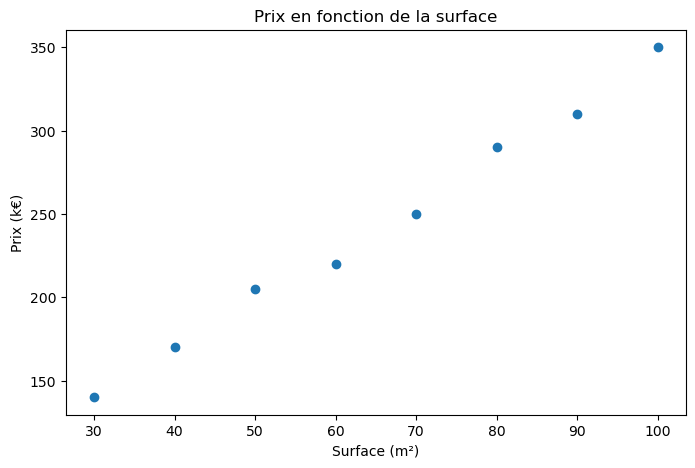

In [54]:
plt.figure(figsize=(8, 5))

plt.scatter(data["surface"], data["price"])

plt.xlabel("Surface (m²)")
plt.ylabel("Prix (k€)")
plt.title("Prix en fonction de la surface")

plt.show()

### Question

À première vue, semble-t-il exister une relation entre la surface et le prix ?

L'objectif d'une régression est de construire une fonction capable de représenter cette relation et de produire des prédictions.


# 4. Première intuition : une droite

Le modèle le plus simple est une droite :

$$
\hat{y} = ax + b
$$

où :

- $x$ est la variable explicative ;
- $\hat{y}$ est la valeur prédite ;
- $a$ est la pente ;
- $b$ est l'ordonnée à l'origine.

Par exemple :

$$
\hat{y} = 3x + 50
$$

signifie que le modèle prédit un prix de :

- 140 k€ pour 30 m² ;
- 200 k€ pour 50 m² ;
- 290 k€ pour 80 m².



## 5. Tracer une première droite

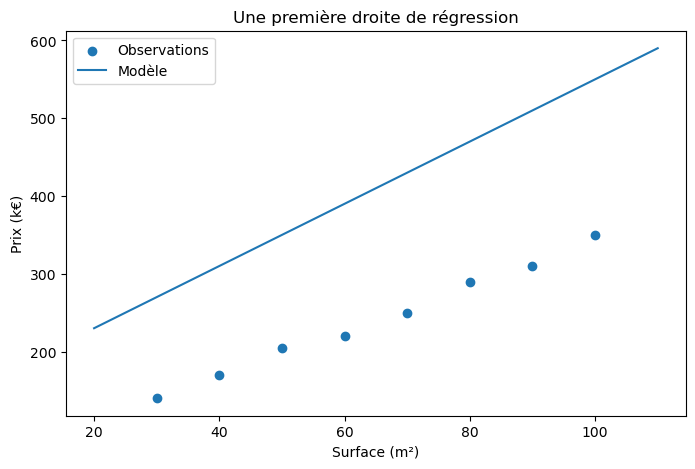

In [55]:
x = np.linspace(20, 110, 100)

a = 4
b = 150

y_pred = a * x + b

plt.figure(figsize=(8, 5))

plt.scatter(data["surface"], data["price"], label="Observations")
plt.plot(x, y_pred, label="Modèle")

plt.xlabel("Surface (m²)")
plt.ylabel("Prix (k€)")
plt.title("Une première droite de régression")
plt.legend()

plt.show()

La droite est un **modèle**.

Elle ne passe pas nécessairement par tous les points.

Son rôle est de capturer la tendance générale.



# 6. Comprendre la pente et l'ordonnée à l'origine (y-intercept)

Pour :

$$
\hat{y} = ax + b
$$

### La pente $a$

La pente indique comment varie la prédiction lorsque $x$ augmente d'une unité.

Si :

$$
a = 3
$$

alors 1 m² supplémentaire augmente le prix prédit de 3 k€.

### L'ordonnée à l'origine $b$

L'ordonnée à l'origine correspond à la valeur prédite lorsque :

$$
x = 0
$$

Dans notre exemple :

$$
\hat{y}=3x+50
$$

donne :

$$
\hat{y}(0)=50
$$

Cette valeur peut être mathématiquement utile sans avoir nécessairement une interprétation métier réaliste.



# 7. Les erreurs de prédiction

Pour chaque observation, notre modèle produit une prédiction.

Le **résidu** est :

$$
e_i = y_i - \hat{y}_i
$$

Il mesure l'écart entre la réalité et la prédiction.

In [56]:
a = 3
b = 50

data["prediction"] = a * data["surface"] + b
data["residual"] = data["price"] - data["prediction"]

data

,surface,price,prediction,residual
0,30,140,140,0
1,40,170,170,0
2,50,205,200,5
3,60,220,230,-10
4,70,250,260,-10
5,80,290,290,0
6,90,310,320,-10
7,100,350,350,0


## 8. Visualiser les résidus

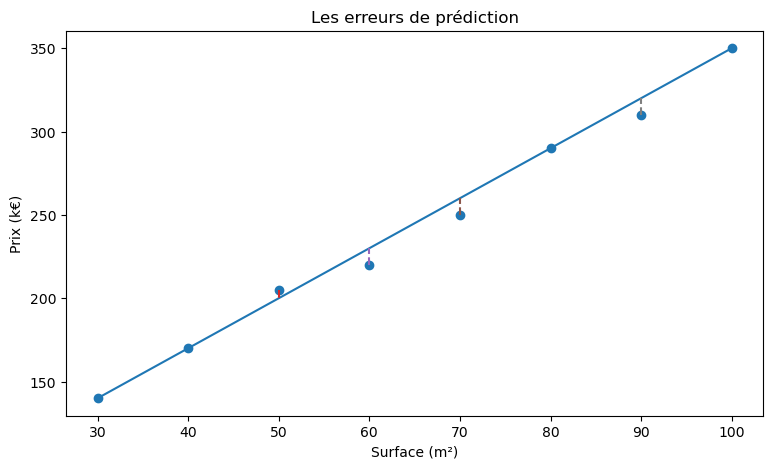

In [57]:
plt.figure(figsize=(9, 5))

plt.scatter(data["surface"], data["price"])

plt.plot(
    data["surface"],
    data["prediction"],
)

for _, row in data.iterrows():
    plt.plot(
        [row["surface"], row["surface"]],
        [row["price"], row["prediction"]],
        linestyle="--",
    )

plt.xlabel("Surface (m²)")
plt.ylabel("Prix (k€)")
plt.title("Les erreurs de prédiction")

plt.show()

Les segments verticaux représentent les erreurs du modèle.



# 9. Comment choisir la meilleure droite ?

Nous pouvons imaginer une infinité de droites.

Comment choisir la meilleure ?

Une première idée serait de calculer la moyenne des erreurs.

Mais cela pose un problème :

$$
(+10) + (-10) = 0
$$

Deux grosses erreurs peuvent donc s'annuler.

Nous allons plutôt utiliser les **erreurs au carré**.



# 10. La fonction de coût : MSE

Le **Mean Squared Error** est défini par :

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

Le principe est simple :

1. calculer chaque erreur ;
2. l'élever au carré ;
3. faire la moyenne.

In [58]:
mse = np.mean(data["residual"] ** 2)

mse

np.float64(40.625)

### Pourquoi le carré ?

Il permet notamment :

- d'éviter l'annulation des erreurs positives et négatives ;
- de pénaliser fortement les grosses erreurs.

Par exemple :

| Erreur | Erreur² |
| -----: | ------: |
|      2 |       4 |
|      5 |      25 |
|     10 |     100 |
|     20 |     400 |

Une erreur deux fois plus importante contribue quatre fois plus au MSE.



# 11. Comparer plusieurs droites

Imaginons plusieurs modèles.

In [59]:
candidate_models = [
    {"a": 2.0, "b": 70},
    {"a": 2.5, "b": 60},
    {"a": 3.0, "b": 50},
    {"a": 3.5, "b": 40},
]

results = []

for candidate in candidate_models:
    predictions = (
        candidate["a"] * data["surface"]
        + candidate["b"]
    )

    mse = np.mean((data["price"] - predictions) ** 2)

    results.append({
        "slope": candidate["a"],
        "intercept": candidate["b"],
        "mse": mse,
    })

pd.DataFrame(results).sort_values("mse")

,slope,intercept,mse
2,3.0,50,40.625
1,2.5,60,496.875
3,3.5,40,859.375
0,2.0,70,2228.125


La meilleure droite parmi ces candidates est celle qui possède le **MSE le plus faible**.



# 12. Une fonction de coût

Notre problème peut maintenant être écrit mathématiquement.

Pour une droite :

$$
\hat{y}=ax+b
$$

nous cherchons les paramètres $a$ et $b$ qui minimisent :

$$
J(a,b)
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-(ax_i+b))^2
$$

Autrement dit :

> **L'apprentissage consiste à trouver les paramètres qui minimisent une fonction de coût.**



# 13. Explorer la fonction de coût

Nous allons faire varier la pente et l'intercept et calculer le MSE.

In [60]:
slopes = np.linspace(1.0, 5.0, 80)
intercepts = np.linspace(0, 120, 80)

loss_surface = np.zeros(
    (len(intercepts), len(slopes))
)

for i, intercept in enumerate(intercepts):
    for j, slope in enumerate(slopes):
        predictions = (
            slope * data["surface"]
            + intercept
        )

        loss_surface[i, j] = np.mean(
            (data["price"] - predictions) ** 2
        )

## 14. Carte de la fonction de coût

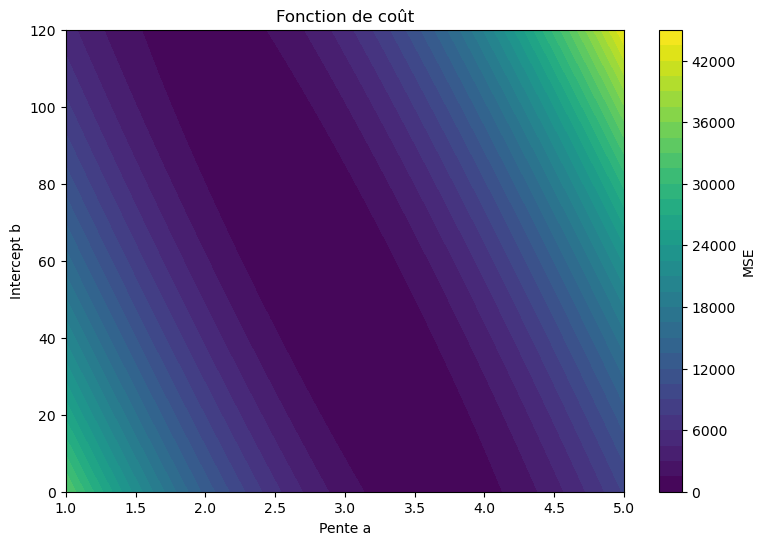

In [61]:
plt.figure(figsize=(9, 6))

plt.contourf(
    slopes,
    intercepts,
    loss_surface,
    levels=30,
)

plt.colorbar(label="MSE")
plt.xlabel("Pente a")
plt.ylabel("Intercept b")
plt.title("Fonction de coût")

plt.show()

Chaque point de cette surface correspond à une droite différente.

Le minimum correspond aux paramètres donnant le plus petit MSE.



# 15. L'idée de la descente de gradient

Une manière générale de rechercher le minimum consiste à utiliser la **descente de gradient**.

L'idée :

```text
Paramètres initiaux
        ↓
Calcul de la fonction de coût
        ↓
Calcul de la direction dans laquelle
le coût diminue
        ↓
Modification des paramètres
        ↓
Nouveau calcul
        ↓
Répétition
        ↓
Minimum
```

On peut imaginer une bille qui descend une montagne :

- la pente indique dans quelle direction descendre ;
- le taux d'apprentissage contrôle la taille des pas ;
- l'objectif est d'atteindre une zone de minimum.



# 16. Une mini-descente de gradient

Pour comprendre le mécanisme, implémentons une version simplifiée.

In [62]:
x_values = data["surface"].to_numpy()
y_values = data["price"].to_numpy()

slope = 0.0
intercept = 0.0

learning_rate = 0.0001
epochs = 5

loss_history = []

n = len(x_values)

for _ in range(epochs):
    predictions = slope * x_values + intercept
    errors = predictions - y_values

    mse = np.mean(errors ** 2)
    loss_history.append(mse)

    slope_gradient = (2 / n) * np.sum(
        x_values * errors
    )

    intercept_gradient = (2 / n) * np.sum(errors)

    slope -= learning_rate * slope_gradient
    intercept -= learning_rate * intercept_gradient

slope, intercept

(np.float64(3.6321515390637207), np.float64(0.055435377707249434))

# 17. Observer l'apprentissage

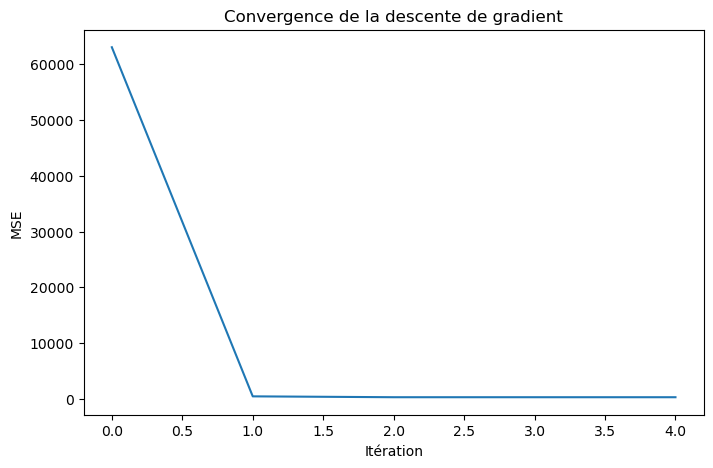

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Itération")
plt.ylabel("MSE")
plt.title("Convergence de la descente de gradient")

plt.show()

Le MSE doit progressivement diminuer.

C'est une première illustration concrète de l'apprentissage d'un modèle.

> **Attention :** `LinearRegression` de scikit-learn n'utilise pas nécessairement cette descente de gradient pour résoudre ce problème. Cette démonstration sert à comprendre le principe général de l'optimisation.



# 18. Régression linéaire avec scikit-learn

Nous pouvons maintenant utiliser une bibliothèque spécialisée.

In [64]:
from sklearn.linear_model import LinearRegression

X = data[["surface"]]
y = data["price"]

model = LinearRegression()

model.fit(X, y)

LinearRegression()

Le modèle possède maintenant des paramètres appris à partir des données.

In [65]:
model.coef_, model.intercept_

(array([2.92261905]), np.float64(51.9047619047619))

# 19. Faire des prédictions

In [66]:
predictions = model.predict(X)

predictions

array([139.58333333, 168.80952381, 198.03571429, 227.26190476,
       256.48809524, 285.71428571, 314.94047619, 344.16666667])

Le modèle peut également prédire le prix d'un nouveau logement.

In [67]:
new_houses = pd.DataFrame({
    "surface": [35, 55, 75, 120]
})

model.predict(new_houses)

array([154.19642857, 212.64880952, 271.10119048, 402.61904762])

# 20. Visualiser le modèle appris

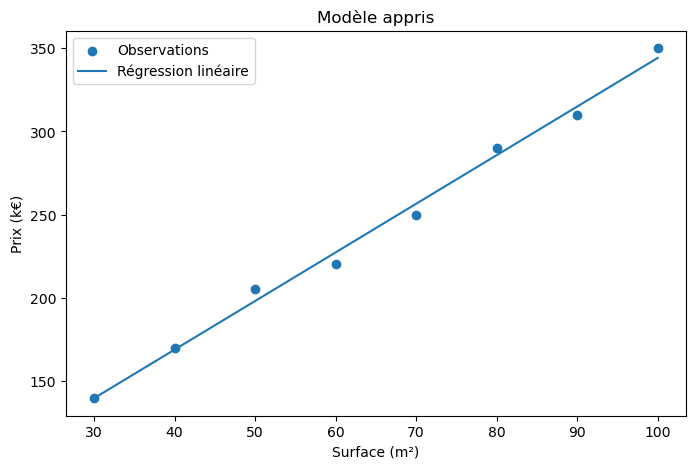

In [68]:
x_line = np.linspace(
    data["surface"].min(),
    data["surface"].max(),
    100,
)

line_data = pd.DataFrame({
    "surface": x_line,
})

y_line = model.predict(line_data)

plt.figure(figsize=(8, 5))

plt.scatter(
    data["surface"],
    data["price"],
    label="Observations",
)

plt.plot(
    x_line,
    y_line,
    label="Régression linéaire",
)

plt.xlabel("Surface (m²)")
plt.ylabel("Prix (k€)")
plt.title("Modèle appris")
plt.legend()

plt.show()

# 21. Évaluer le modèle

Plusieurs métriques sont couramment utilisées.

## MAE — Mean Absolute Error

$$
MAE =
\frac{1}{n}
\sum |y_i-\hat y_i|
$$

In [69]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y, predictions)

mae

4.6726190476190474

Le MAE est particulièrement facile à interpréter :

> En moyenne, notre modèle se trompe de `MAE` k€.



## 22. MSE

In [70]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, predictions)

mse

27.715773809523746

Le MSE pénalise davantage les grosses erreurs.



## 23. RMSE

Le RMSE est la racine carrée du MSE :

$$
RMSE = \sqrt{MSE}
$$

In [71]:
rmse = np.sqrt(mse)

rmse

np.float64(5.264577267884264)

L'intérêt principal est qu'il revient dans la même unité que la variable cible.

Si le prix est exprimé en k€, le RMSE est également exprimé en k€.



# 24. Le coefficient $R^2$

Le coefficient de détermination mesure la capacité du modèle à expliquer la variabilité observée dans la cible. 

$R^2$ donne une indication sur la variabilité observée grace à l'utilisation du modèle par rapport à une prédiction basée uniquement sur la moyenne.

In [72]:
from sklearn.metrics import r2_score

r2 = r2_score(y, predictions)

r2

0.9938574685349857

Une valeur proche de 1 indique que le modèle explique une grande partie de la variabilité observée.

Mais :

> **Un $R^2$ élevé ne garantit pas qu'un modèle soit utile ou qu'il généralise bien.**

Nous devons évaluer le modèle sur des données qu'il n'a pas vues.


# 25. Pourquoi séparer train et test ?

Si nous entraînons et évaluons le modèle sur les mêmes observations :

```mermaid
flowchart LR
    A["Jeu de données complet"] --> B["Séparation train / test"]

    B --> C["Données d'entraînement - 80 %"]
    B --> D["Données de test - 20 %"]

    C --> E["Entraînement du modèle : model.fit"]
    E --> F["Modèle appris"]

    D --> G["Prédictions : model.predict"]
    F --> G

    G --> H["Évaluation : MAE, RMSE, R2"]

    style C fill:#d9f2d9
    style D fill:#f8d7da
    style F fill:#d9eaf7
    style H fill:#fff3cd
```

In [73]:
model.fit(X, y)

predictions = model.predict(X)

nous ne mesurons pas réellement sa capacité à généraliser.

C'est comparable à donner les réponses d'un examen à un étudiant puis à lui faire passer exactement le même examen.



# 26. Séparation train / test

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

Nous avons maintenant :

- un ensemble d'entraînement ;
- un ensemble de test.

In [75]:
print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 6
Test: 2


# 27. Entraîner et évaluer

In [76]:
model = LinearRegression()

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

Calculons les performances.

In [77]:
train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train RMSE: 5.73
Test RMSE: 3.98


La performance sur le test est plus importante pour estimer la capacité de généralisation.



# 28. Construire un jeu de données multivarié

In [85]:
np.random.seed(42)

n_samples = 100

data_multiple = pd.DataFrame({
    "surface": np.random.uniform(30, 150, n_samples),
    "bedrooms": np.random.randint(1, 6, n_samples),
    "distance_to_center": np.random.uniform(
        1, 20, n_samples
    ),
    "age": np.random.randint(0, 80, n_samples),
})

data_multiple["price"] = (
    80
    + 2.8 * data_multiple["surface"]
    + 15 * data_multiple["bedrooms"]
    - 4 * data_multiple["distance_to_center"]
    - 0.8 * data_multiple["age"]
    + np.random.normal(0, 20, n_samples)
)

data_multiple.head()

,surface,bedrooms,distance_to_center,age,price
0,74.944814,1,14.969106,14,210.870084
1,144.085717,4,4.972361,65,483.376886
2,117.839273,5,11.287512,31,397.338345
3,101.839018,4,14.219904,62,304.682075
4,48.722237,5,5.342450,50,221.682284


# 29. Passage à plusieurs variables

Jusqu'à maintenant :

$$
\hat y = \beta_0+\beta_1x_1
$$

Mais le prix d'un logement dépend probablement de plusieurs caractéristiques.

Par exemple :

- surface ;
- nombre de chambres ;
- distance au centre ;
- âge du bâtiment.

Le modèle devient :

$$
\hat y =
\beta_0
+\beta_1x_1
+\beta_2x_2
+\dots
+\beta_px_p
$$

C'est la **régression linéaire multiple**.


Ordonnée à l'origine : 9.116369862112947
Coefficients : [ 2.77574936 13.65414645]


/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


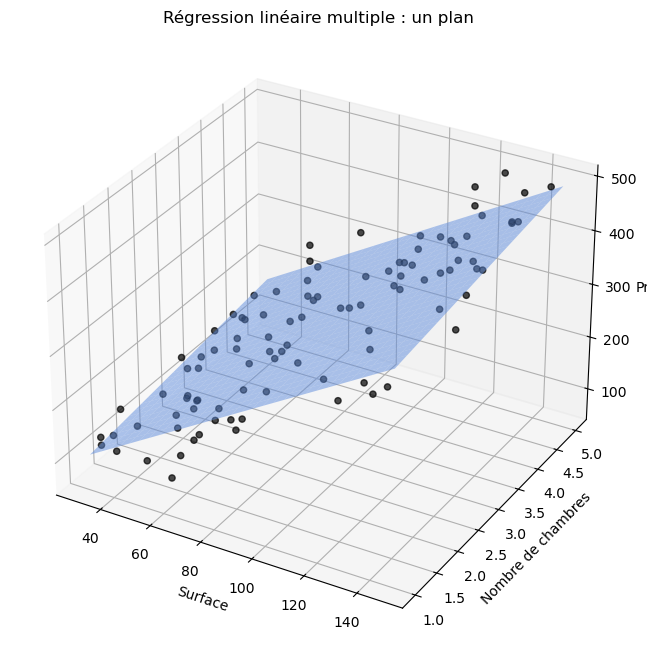

In [79]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Deux variables explicatives
features = ["surface", "bedrooms"]

X = data_multiple[features]
y = data_multiple["price"]

# Entraînement du modèle
model_2d = LinearRegression()
model_2d.fit(X, y)

# Paramètres appris
print("Ordonnée à l'origine :", model_2d.intercept_)
print("Coefficients :", model_2d.coef_)

# Création d'une grille de valeurs pour dessiner le plan
surface_values = np.linspace(
    data_multiple["surface"].min(),
    data_multiple["surface"].max(),
    30,
)

bedrooms_values = np.linspace(
    data_multiple["bedrooms"].min(),
    data_multiple["bedrooms"].max(),
    30,
)

surface_grid, bedrooms_grid = np.meshgrid(
    surface_values,
    bedrooms_values,
)

# Prédiction du prix sur chaque point de la grille
grid_data = np.column_stack(
    [
        surface_grid.ravel(),
        bedrooms_grid.ravel(),
    ]
)

price_grid = model_2d.predict(grid_data)
price_grid = price_grid.reshape(surface_grid.shape)

# Représentation graphique
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

# Observations réelles
ax.scatter(
    data_multiple["surface"],
    data_multiple["bedrooms"],
    data_multiple["price"],
    color="black",
    alpha=0.7,
    label="Observations",
)

# Plan de régression
ax.plot_surface(
    surface_grid,
    bedrooms_grid,
    price_grid,
    alpha=0.5,
    color="cornflowerblue",
)

ax.set_xlabel("Surface")
ax.set_ylabel("Nombre de chambres")
ax.set_zlabel("Prix")
ax.set_title("Régression linéaire multiple : un plan")

plt.show()

In [80]:
print(
    f"prix = {model_2d.intercept_:.2f}"
    f" + {model_2d.coef_[0]:.2f} * surface"
    f" + {model_2d.coef_[1]:.2f} * bedrooms"
)

prix = 9.12 + 2.78 * surface + 13.65 * bedrooms


En plus haute dimension, Lorsque le nombre de variables explicatives augmente, la régression linéaire cherche l’hyperplan qui ajuste au mieux les données afin de prédire la variable cible.

# 30. Construire le modèle multiple

In [81]:
features = [
    "surface",
    "bedrooms",
    "distance_to_center",
    "age",
]

X = data_multiple[features]
y = data_multiple["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# 31. Interpréter les coefficients

In [82]:
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_,
})

coefficients

,feature,coefficient
0,surface,2.842118
1,bedrooms,16.750915
2,distance_to_center,-3.159232
3,age,-0.942588


On peut interpréter chaque coefficient comme l'effet d'une augmentation d'une unité de la variable, **toutes les autres variables étant maintenues constantes**.

Par exemple, si :

$$
\beta_{surface}=2.8
$$

alors :

> Une augmentation de 1 m² est associée à une augmentation de 2,8 k€ du prix prédit, toutes choses égales par ailleurs.

Cette interprétation est fondamentale en Data Science.



# 32. Évaluer le modèle multiple

In [83]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

MAE  : 20.44
RMSE : 24.77
R²   : 0.949


# 33. Comparer modèle simple et modèle multiple

Nous pouvons maintenant comparer :

### Modèle 1

$$
prix=f(surface)
$$

### Modèle 2

$$
prix=f(
surface,
chambres,
distance,
age
)
$$

La question n'est pas seulement :

> « Quel modèle a le meilleur score ? »

Il faut également se demander :

- Les nouvelles variables apportent-elles réellement de l'information ?
- Le modèle généralise-t-il mieux ?
- Les coefficients sont-ils interprétables ?
- Certaines variables sont-elles fortement corrélées ?
- Le modèle est-il suffisamment simple pour le besoin ?



# 34. Une première lecture des résidus

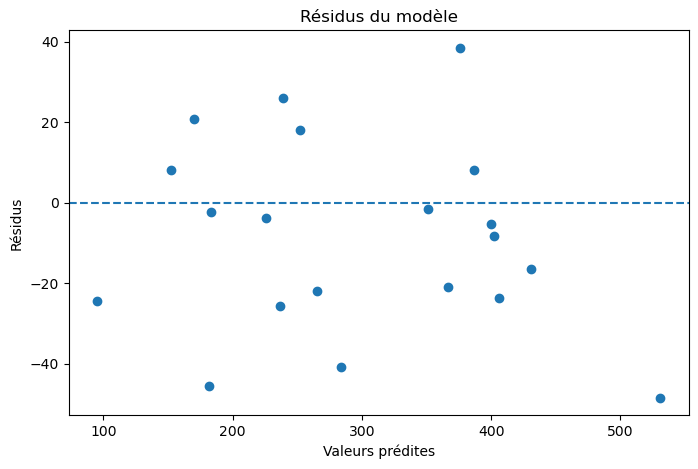

In [84]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus du modèle")

plt.show()

Un bon modèle linéaire devrait généralement produire des résidus sans structure évidente.

Une structure peut révéler :

- une relation non linéaire ;
- une variance non constante ;
- des observations atypiques ;
- des variables manquantes.



# 35. Synthèse

Nous avons construit progressivement une régression linéaire.

```text
Données
   ↓
Relation entre X et Y
   ↓
Droite
   ↓
Prédictions
   ↓
Résidus
   ↓
MSE
   ↓
Optimisation
   ↓
Paramètres appris
   ↓
Évaluation
   ↓
Généralisation
   ↓
Régression multiple
```

Les notions essentielles à retenir :

### 1. Un modèle

$$
\hat y = ax+b
$$

### 2. Une erreur

$$
e=y-\hat y
$$

### 3. Une fonction de coût

$$
MSE=\frac{1}{n}\sum(y-\hat y)^2
$$

### 4. Un apprentissage

> Trouver les paramètres qui minimisent la fonction de coût.

### 5. Une évaluation

> Tester les performances sur des données nouvelles.

### 6. Une extension

$$
\hat y =
\beta_0+\beta_1x_1+\dots+\beta_px_p
$$



# 36. À retenir avant le TP

Avant de passer à la pratique, vous devez être capables de répondre à ces questions :

1. Qu'est-ce qu'un problème de régression ?
2. Que représentent $a$ et $b$ dans une droite ?
3. Qu'est-ce qu'un résidu ?
4. Pourquoi utilise-t-on le carré des erreurs ?
5. Que cherche-t-on à minimiser ?
6. Quel est le principe de la descente de gradient ?
7. Quelle différence entre MAE, MSE et RMSE ?
8. À quoi sert $R^2$ ?
9. Pourquoi séparer les données en train et test ?
10. Comment interpréter un coefficient dans une régression multiple ?



# 37. Transition vers le TP

> **Mission : construire un modèle capable de prédire la consommation énergétique d'un bâtiment.**

Vous devrez :

- explorer les données ;
- identifier la variable cible ;
- rechercher les relations entre variables ;
- construire une première régression ;
- évaluer ses performances ;
- ajouter plusieurs variables ;
- comparer les modèles ;
- analyser les résidus ;
- identifier les limites du modèle.

**Objectif final : ne pas seulement obtenir un modèle qui fonctionne, mais être capable d'expliquer pourquoi vous lui faites — ou non — confiance.**